In [1]:
import scanpy as sc

adata = sc.read_h5ad("../data/Variant_Vax_obj.h5ad")

# Get a full picture of what's stored
print(adata)
print("---")
print("Layers:", list(adata.layers.keys()))
print("Raw exists:", adata.raw is not None)
print("X dtype:", adata.X.dtype)          # int = counts, float = normalized
print("X max value:", adata.X.max())      # >100 suggests raw counts
print("obsm keys:", list(adata.obsm.keys()))  # should see X_pca, X_umap
print("obs columns:", list(adata.obs.columns))  # cell metadata, patient IDs etc

AnnData object with n_obs × n_vars = 48730 × 29961
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Variant_Group', 'Participant', 'SARSCoV2_PCR_Status', 'Vaccination_Status', 'WHO_Score_at_Peak', 'SingleCell_SARSCoV2_RNA_Status', 'Coarse_Annotation', 'Detailed_Annotation', 'Variant_Vax_Group'
    obsm: 'X_harmony', 'X_pca', 'X_umap'
---
Layers: []
Raw exists: False
X dtype: int64
X max value: 1138
obsm keys: ['X_harmony', 'X_pca', 'X_umap']
obs columns: ['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Variant_Group', 'Participant', 'SARSCoV2_PCR_Status', 'Vaccination_Status', 'WHO_Score_at_Peak', 'SingleCell_SARSCoV2_RNA_Status', 'Coarse_Annotation', 'Detailed_Annotation', 'Variant_Vax_Group']


In [2]:
import numpy as np

# Raw counts should be:
# 1. All non-negative
# 2. All whole numbers
# 3. Sparse (lots of zeros)

sample = adata.X[:500].toarray()

print("Any negatives?", (sample < 0).any())          # should be False
print("All integers?", (sample == sample.astype(int)).all())  # should be True
print("Sparsity:", (sample == 0).mean())              # should be >0.8
print("Value distribution:")
unique, freq = np.unique(sample, return_counts=True)
for v, f in zip(unique[:10], freq[:10]):
    print(f"  value {int(v)}: {f} times")

Any negatives? False
All integers? True
Sparsity: 0.9628999699609493
Value distribution:
  value 0: 14424723 times
  value 1: 415568 times
  value 2: 86454 times
  value 3: 27636 times
  value 4: 10072 times
  value 5: 4752 times
  value 6: 2825 times
  value 7: 1693 times
  value 8: 1212 times
  value 9: 881 times


In [4]:
print(adata.obs["Participant"].nunique())
print(adata.obs["Participant"].value_counts())

112
Participant
D_COVID19_08    1744
D_COVID19_06    1690
D_COVID19_24    1598
A_COVID19_04    1497
A_COVID19_28    1465
                ... 
CONTROL_02        40
D_COVID19_16      40
D_COVID19_32      38
A_COVID19_19      35
O_COVID19_09      32
Name: count, Length: 112, dtype: int64


In [5]:
# Check distribution
print(adata.obs["Participant"].value_counts().describe())

# How many patients have fewer than 100 cells?
counts = adata.obs["Participant"].value_counts()
print(f"Patients with <100 cells: {(counts < 100).sum()}")

count     112.000000
mean      435.089286
std       382.371442
min        32.000000
25%       165.750000
50%       331.500000
75%       575.250000
max      1744.000000
Name: count, dtype: float64
Patients with <100 cells: 19


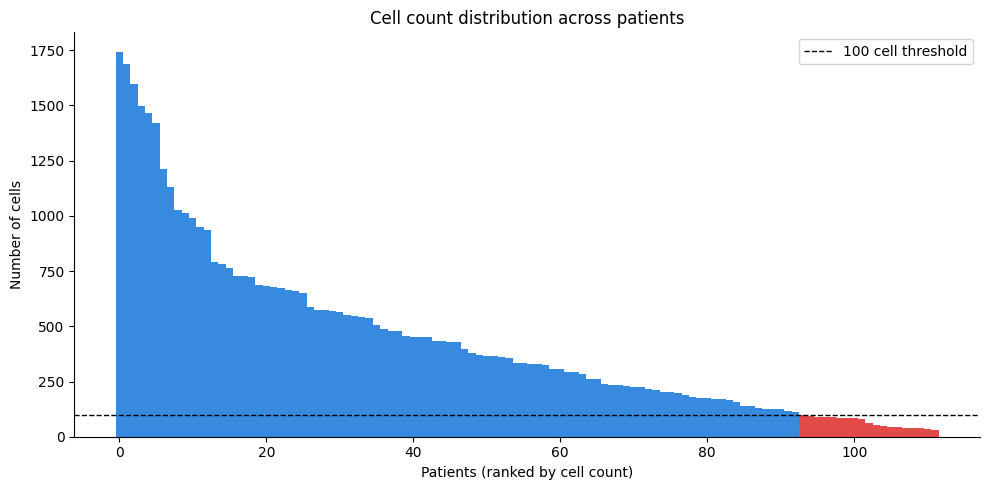

Patients below 100 cells: 19
Patients above 100 cells: 93


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

cell_counts = adata.obs["Participant"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#E24B4A" if c < 100 else "#378ADD" for c in cell_counts]

ax.bar(range(len(cell_counts)), cell_counts.values, color=colors, width=1.0)

ax.axhline(y=100, color="black", linestyle="--", linewidth=1, label="100 cell threshold")

ax.set_xlabel("Patients (ranked by cell count)")
ax.set_ylabel("Number of cells")
ax.set_title("Cell count distribution across patients")
ax.legend()

sns.despine()
plt.tight_layout()
plt.show()

print(f"Patients below 100 cells: {(cell_counts < 100).sum()}")
print(f"Patients above 100 cells: {(cell_counts >= 100).sum()}")